,n_non_zero_genre_scores,n_songs
0,0,27
1,1,33120
2,2,38315
3,3,26236
4,4,9266
5,5,1908
6,6,393
7,7,4


../plots/Exploration/candidate_genres_per_song.png


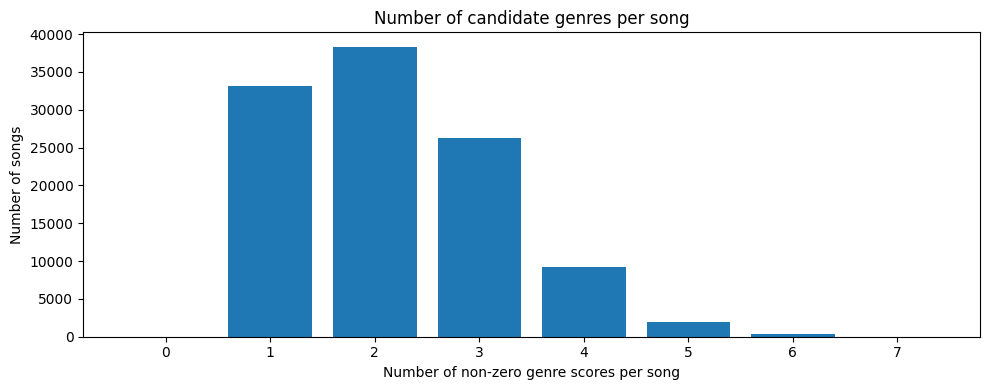

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PLOTS_DIR = Path("../plots/Exploration")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

genre_scores = pd.read_csv("../data/raw/id_genres_tf-idf.tsv", sep="\t")

genre_score_columns = [
    column for column in genre_scores.columns
    if column != "id"
]

non_zero_counts = (genre_scores[genre_score_columns] > 0).sum(axis=1)

non_zero_count_overview = (
    non_zero_counts
    .value_counts()
    .sort_index()
    .reset_index()
)

non_zero_count_overview.columns = [
    "n_non_zero_genre_scores",
    "n_songs",
]

display(non_zero_count_overview)

plt.figure(figsize=(10, 4))

plt.bar(
    non_zero_count_overview["n_non_zero_genre_scores"],
    non_zero_count_overview["n_songs"],
)

plt.xlabel("Number of non-zero genre scores per song")
plt.ylabel("Number of songs")
plt.title("Number of candidate genres per song")
plt.tight_layout()

output_path = PLOTS_DIR / "candidate_genres_per_song.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

../plots/Exploration/songs_and_valid_genres_per_year.png


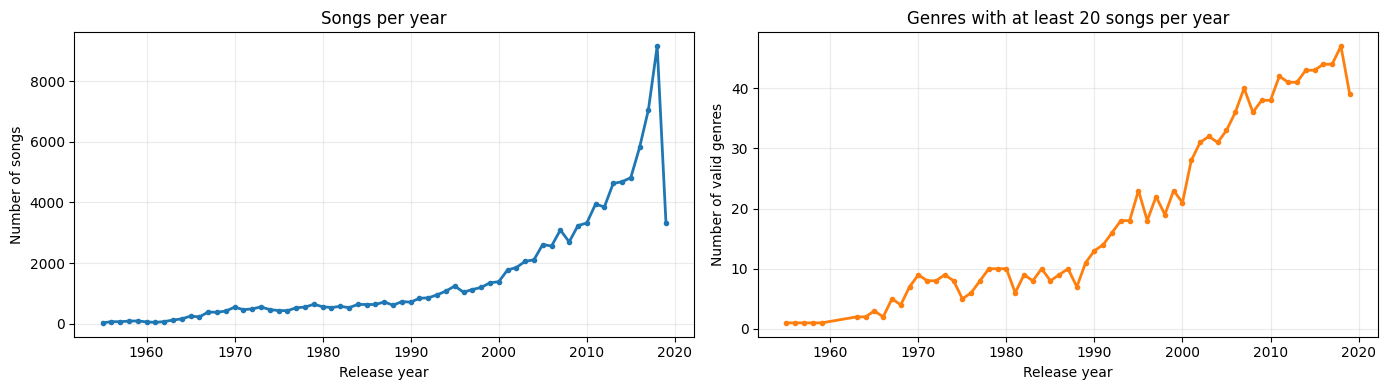

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PLOTS_DIR = Path("../plots/Exploration")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

min_tracks_per_valid_genre = 20

assignments = pd.read_parquet(
    "../data/processed/09_selected_genres_ortools/"
    "ortools_top50_mintracks20_topcandidates5_genrepool180_assignments.parquet"
)

assignments["release"] = pd.to_numeric(assignments["release"], errors="coerce")
assignments = assignments.dropna(subset=["release", "genre"]).copy()
assignments["release"] = assignments["release"].astype(int)

songs_per_year = (
    assignments
    .groupby("release")["id"]
    .nunique()
    .reset_index(name="n_songs")
    .sort_values("release")
)

valid_genres_per_year = (
    assignments
    .groupby(["release", "genre"])["id"]
    .nunique()
    .reset_index(name="n_tracks")
)

valid_genres_per_year = (
    valid_genres_per_year[
        valid_genres_per_year["n_tracks"] >= min_tracks_per_valid_genre
    ]
    .groupby("release")["genre"]
    .nunique()
    .reset_index(name="n_valid_genres")
    .sort_values("release")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

axes[0].plot(
    songs_per_year["release"],
    songs_per_year["n_songs"],
    marker="o",
    markersize=3,
    linewidth=2,
)

axes[0].set_xlabel("Release year")
axes[0].set_ylabel("Number of songs")
axes[0].set_title("Songs per year")
axes[0].grid(alpha=0.25)

axes[1].plot(
    valid_genres_per_year["release"],
    valid_genres_per_year["n_valid_genres"],
    marker="o",
    markersize=3,
    linewidth=2,
    color="tab:orange",
)

axes[1].set_xlabel("Release year")
axes[1].set_ylabel("Number of valid genres")
axes[1].set_title(
    f"Genres with at least {min_tracks_per_valid_genre} songs per year"
)
axes[1].grid(alpha=0.25)

plt.tight_layout()

output_path = PLOTS_DIR / "songs_and_valid_genres_per_year.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

../plots/Exploration/final_ortools_dataset_songs_and_valid_genres_per_window.png


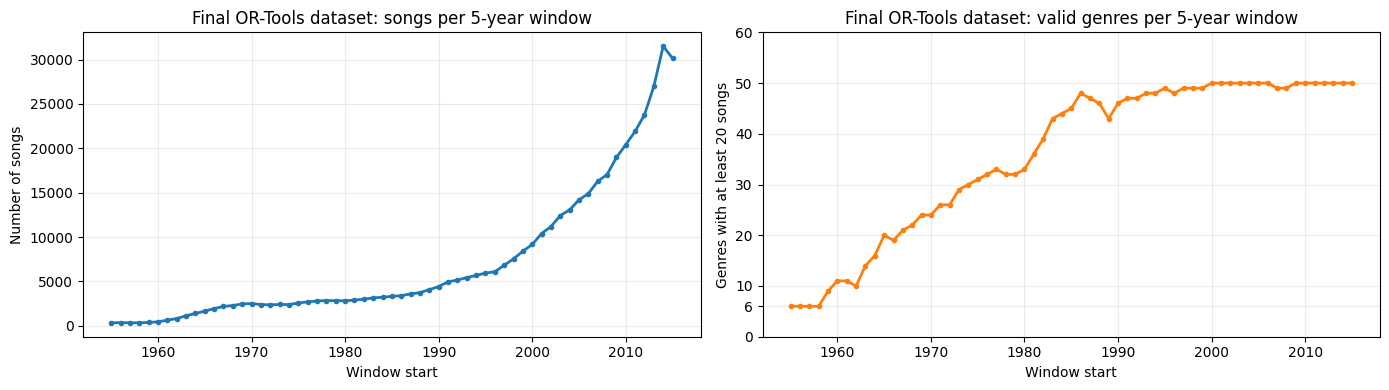

In [9]:
analysis_min_year = 1955
analysis_max_year = 2019
window_size = 5
hop_size = 1
min_tracks_per_valid_genre_window = 20

window_rows = []

for window_start in range(
    analysis_min_year,
    analysis_max_year - window_size + 2,
    hop_size,
):
    window_end = window_start + window_size - 1

    window_data = assignments[
        assignments["release"].between(window_start, window_end)
    ]

    genre_counts = (
        window_data
        .groupby("genre")["id"]
        .nunique()
        .reset_index(name="n_tracks")
    )

    n_valid_genres = (
        genre_counts["n_tracks"] >= min_tracks_per_valid_genre_window
    ).sum()

    window_rows.append({
        "window_start": window_start,
        "window_end": window_end,
        "n_songs": window_data["id"].nunique(),
        "n_genres": window_data["genre"].nunique(),
        "n_valid_genres": n_valid_genres,
    })

window_coverage = pd.DataFrame(window_rows)

start_n_valid_genres = int(window_coverage["n_valid_genres"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

axes[0].plot(
    window_coverage["window_start"],
    window_coverage["n_songs"],
    marker="o",
    markersize=3,
    linewidth=2,
)

axes[0].set_title("Final OR-Tools dataset: songs per 5-year window")
axes[0].set_xlabel("Window start")
axes[0].set_ylabel("Number of songs")
axes[0].grid(alpha=0.25)

axes[1].plot(
    window_coverage["window_start"],
    window_coverage["n_valid_genres"],
    marker="o",
    markersize=3,
    linewidth=2,
    color="tab:orange",
)

axes[1].set_title(
    "Final OR-Tools dataset: valid genres per 5-year window"
)
axes[1].set_xlabel("Window start")
axes[1].set_ylabel("Genres with at least 20 songs")
axes[1].grid(alpha=0.25)

default_genre_ticks = axes[1].get_yticks()
genre_ticks = sorted(set(default_genre_ticks.tolist() + [start_n_valid_genres]))
axes[1].set_yticks(genre_ticks)

plt.tight_layout()

output_path = (
    PLOTS_DIR
    / "final_ortools_dataset_songs_and_valid_genres_per_window.png"
)
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

In [12]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


try:
    from helper_functions import PROCESSED_DIR
except ImportError:
    PROJECT_ROOT = Path.cwd()

    PROJECT_ROOT = PROJECT_ROOT.parent

    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RQ2_ESSENTIA_DIR = PROCESSED_DIR / "RQ2_essentia_interpretable_features"
PLOTS_DIR = PROJECT_ROOT / "plots" / "RQ2_essentia_interpretable_features"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

metadata_tracks = pd.read_parquet(
    PROCESSED_DIR / "RQ2_metadata_interpretable_features" / "metadata_assignments_prepared.parquet"
)

essentia_tracks = pd.read_parquet(
    PROCESSED_DIR / "essentia.parquet"
)

metadata_ids = set(metadata_tracks["id"])
essentia_ids = set(essentia_tracks["id"])

print("Metadata tracks:", len(metadata_ids))
print("Essentia tracks:", len(essentia_ids))
print("Overlap:", len(metadata_ids & essentia_ids))
print("Metadata only:", len(metadata_ids - essentia_ids))
print("Essentia only:", len(essentia_ids - metadata_ids))

Metadata tracks: 97883
Essentia tracks: 109180
Overlap: 97805
Metadata only: 78
Essentia only: 11375


In [13]:
combined_corr_data[["window_start", "metadata:tempo", "essentia:rhythm.bpm"]].head(20)

NameError: name 'combined_corr_data' is not defined